In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
import os

## Simplified dot plots

In [2]:
### helper funcs
def h2r(h):
    """
    converts hex to rgb
    """
    h = h.replace("#","").upper()
    return [x/255 for x in list(int(h[i:i+2], 16) for i in (0, 2, 4))]

def inverse_color(hexcolor):
    """
    Takes in a hex color and determines if the text should be black or white

    This is used for determining the color of text in the cells

    taken from: https://stackoverflow.com/questions/3942878
    """
    red,green,blue = [x*255 for x in h2r(hexcolor)]

    if hexcolor == "#000000":
        return "#000000"

    if (red*0.299 + green*0.587 + blue*0.114) > 186:
        return "#000000"
    else:
        return "#ffffff"

def chromsize_to_s2c2s(chromsize_path):
    """
    this reads in a chromsize file and returns a dictionary of species to scaffold to scaflen
    """
    s2c2s = {}
    with open(chromsize_path, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                thissp, thisscaf, thislen = line.split("\t")
                if thissp not in s2c2s:
                    s2c2s[thissp] = {}
                s2c2s[thissp][thisscaf] = int(thislen)
    return s2c2s

In [3]:
def FET_bfs(graph, start):
    """
    This code taken from this SO question: https://stackoverflow.com/questions/53573865
     and this specific answer: https://stackoverflow.com/a/53574094/5843327
     by SO user: https://stackoverflow.com/users/4001592/dani-mesejo
    """
    visited, queue = set(), [start]
    while queue:
        vertex = queue.pop(0)
        if vertex not in visited:
            visited.add(vertex)
            queue.extend(graph[vertex] - visited)
    return visited

def FET_connected_components(G):
    """
    This code taken from this SO question: https://stackoverflow.com/questions/53573865
     and this specific answer: https://stackoverflow.com/a/53574094/5843327
     by SO user: https://stackoverflow.com/users/4001592/dani-mesejo
    """
    seen = set()
    for v in G:
        if v not in seen:
            c = set(FET_bfs(G, v))
            yield c
            seen.update(c)

def FET_graph(edge_list, G = None):
    """
    This code taken from this SO question: https://stackoverflow.com/questions/53573865
     and this specific answer: https://stackoverflow.com/a/53574094/5843327
     by SO user: https://stackoverflow.com/users/4001592/dani-mesejo

    The parameters are set up so that a graph can be made from just a list of edges,
        or a graph can be added to an existing graph.
    """
    result = {}
    if G is not None:
        result = G
    for source, target in edge_list:
        result.setdefault(source, set()).add(target)
        result.setdefault(target, set()).add(source)
    return result

def FET_sample_to_chrom_to_CC(components, xsample, ysample, splitter):
    """
    Turns this into something we can use to assign connected components.
    """
    # convert components into a dictionary for the x or y-chroms lookup. We just want the CC, because we can filter on these later
    sample_to_chrom_to_CC = {xsample: {}, ysample: {}}
    cc_counter = 0
    for CC in components:
        for scaf in CC:
            esample = scaf.split(splitter)[0]
            echrom  = scaf.split(splitter)[1]
            # check if we have seen this already, if so, raise an error
            if sample_to_chrom_to_CC[esample].get(echrom, None) is not None:
                raise ValueError("ERROR: we have seen this chrom before, but it is in a different CC. This should not happen. We saw {}.".format(echrom))
            sample_to_chrom_to_CC[esample][echrom] = cc_counter
        cc_counter += 1
    return sample_to_chrom_to_CC

In [12]:
def synteny_plot_sheet_simple(df_file, synplot, xsample, xspecies, ysample, yspecies, color, xorder=[], yorder=[]):
    df = pd.read_csv(df_file, delimiter="\t")
    df.columns = df.columns.str.strip()

    # Fill FET columns if missing (Raw RBH support)
    cols_to_fix = ['break_FET', 'whole_FET', f"{xsample}_D", f"{ysample}_D"]
    for col in cols_to_fix:
        if col not in df.columns:
            df[col] = 0.0

    # Filter Scaffolds
    target_contigs = [r'ctg1\b', r'ctg2\b', r'ctg3\b', r'ctg277\b', r'ctg278\b', r'ctg279\b']
    final_regex = f"NC|{'|'.join(target_contigs)}"
    # final_regex = f"Chr|{'|'.join(target_contigs)}"

    df = df[df[f"{xsample}_scaf"].astype(str).str.contains(final_regex, regex=True)]
    df = df[df[f"{ysample}_scaf"].astype(str).str.contains("NC")]

    # Sort scaffolds
    sort_df = df.copy()
    keep_cols = [f"{xsample}_scaf", f"{ysample}_scaf", f"{xsample}_ix", f"{ysample}_ix", "whole_FET"]
    sort_df = sort_df[keep_cols]

    # Calculate sizes and merge
    size_df = sort_df.groupby([f"{xsample}_scaf", f"{ysample}_scaf"]).size().to_frame('size').reset_index()
    sort_df = sort_df.groupby([f"{xsample}_scaf", f"{ysample}_scaf"], dropna=False).mean().reset_index()
    sort_df = sort_df.merge(size_df, on=[f"{xsample}_scaf", f"{ysample}_scaf"], how="left")
    
    y_chr_size = df.groupby(f"{ysample}_scaf").size().to_frame(f"{xsample}_size").reset_index()
    x_chr_size = df.groupby(f"{xsample}_scaf").size().to_frame(f"{ysample}_size").reset_index()
    sort_df = sort_df.merge(y_chr_size, on=f"{ysample}_scaf").merge(x_chr_size, on=f"{xsample}_scaf")
    
    # Connected Components Logic
    splitter = ":;:;:;:"
    sort_df[f"{xsample}_scaf_abs"] = f"{xsample}{splitter}" + sort_df[f"{xsample}_scaf"].astype(str)
    sort_df[f"{ysample}_scaf_abs"] = f"{ysample}{splitter}" + sort_df[f"{ysample}_scaf"].astype(str)
    
    G = FET_graph(sort_df.loc[sort_df["whole_FET"] <= 0.05, [f"{xsample}_scaf_abs", f"{ysample}_scaf_abs"]].values)
    components = [set(x) for x in FET_connected_components(G)]
    
    # Handle unplaced and remaining CCs
    sample_to_chrom_to_CC = FET_sample_to_chrom_to_CC(components, xsample, ysample, splitter)
    
    # Ensure all scaffolds have a CC group
    for samp in [xsample, ysample]:
        missing = set(sort_df[f"{samp}_scaf"].unique()) - set(sample_to_chrom_to_CC[samp].keys())
        for m in missing:
            components.append(set([f"{samp}{splitter}{m}"]))
            sample_to_chrom_to_CC = FET_sample_to_chrom_to_CC(components, xsample, ysample, splitter)

    sort_df['CC_group'] = sort_df[f"{xsample}_scaf"].map(sample_to_chrom_to_CC[xsample])

    # Optimize Order Algorithm
    CCs_seen = set()
    x_scafs_by_size = df[f"{xsample}_scaf"].value_counts().index.tolist()
    optimized_x, optimized_y = [], []

    for thisx in x_scafs_by_size:
        if thisx not in optimized_x:
            this_CC = sample_to_chrom_to_CC[xsample][thisx]
            CCs_seen.add(this_CC)
            x_keeps = [x for x in sample_to_chrom_to_CC[xsample] if sample_to_chrom_to_CC[xsample][x] == this_CC]
            x_group = [x for x in x_scafs_by_size if x in x_keeps]
            temp_df = sort_df.loc[sort_df["CC_group"] == this_CC]
            for tempx in x_group:
                sub = temp_df.loc[temp_df[f"{xsample}_scaf"] == tempx].sort_values(f"{xsample}_ix")
                optimized_x.append(tempx)
                for tempy in sub[f"{ysample}_scaf"].unique():
                    if tempy not in optimized_y: optimized_y.append(tempy)

    xsorter, ysorter = optimized_x, optimized_y

    # 4. Generate Plotting Data
    def get_global_indices(data, sample, sorter):
        gb = data.groupby(f"{sample}_scaf")
        ordered = pd.concat([gb.get_group(x).sort_values(f"{sample}_ix") for x in sorter if x in gb.groups])
        ordered[f"{sample}_plotindex"] = range(len(ordered))
        return ordered

    x_ordered_df = get_global_indices(df, xsample, xsorter)
    plotdf = get_global_indices(x_ordered_df, ysample, ysorter)

    # 5. Aesthetics & Plotting
    dot_size = 3
    sig_alpha, nonsig_alpha = 1.0, 0.3
    line_color = [0, 0.169, 0.357, 0.3]

    if "color" not in plotdf.columns: plotdf["color"] = color
    else: plotdf.loc[plotdf["color"].isin(["#000000", "black"]), "color"] = color
    
    rgb = np.array([h2r(c) for c in plotdf["color"]])
    alphas = np.array([[sig_alpha] if p <= 0.05 else [nonsig_alpha] for p in plotdf["break_FET"]])
    composite = np.hstack((rgb, alphas))

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.scatter(plotdf[f"{xsample}_plotindex"], plotdf[f"{ysample}_plotindex"], c=composite, s=dot_size, edgecolors='none')

    # Grid Lines
    for x_val in plotdf.groupby(f"{xsample}_scaf")[f"{xsample}_plotindex"].max().loc[xsorter[:-1]]:
        ax.axvline(x=x_val + 0.5, color=line_color, lw=0.5)
    for y_val in plotdf.groupby(f"{ysample}_scaf")[f"{ysample}_plotindex"].max().loc[ysorter[:-1]]:
        ax.axhline(y=y_val + 0.5, color=line_color, lw=0.5)

    # Labels
    def format_name(n):
        p = n.split(); return rf"$\mathit{{{p[0]}\ {p[1]}}}$ {' '.join(p[2:])}" if len(p)>=2 else n
    
    ax.set_xlabel(format_name(xspecies), fontsize=12)
    ax.set_ylabel(format_name(yspecies), fontsize=12)

    if len(xsorter) < 30:
        ax.set_xticks(plotdf.groupby(f"{xsample}_scaf")[f"{xsample}_plotindex"].mean().loc[xsorter])
        ax.set_xticklabels(xsorter, rotation=90, fontsize=8)
        ax.set_yticks(plotdf.groupby(f"{ysample}_scaf")[f"{ysample}_plotindex"].mean().loc[ysorter])
        ax.set_yticklabels(ysorter, rotation=0, fontsize=8)

    plt.tight_layout()
    plt.savefig(synplot, dpi=300)

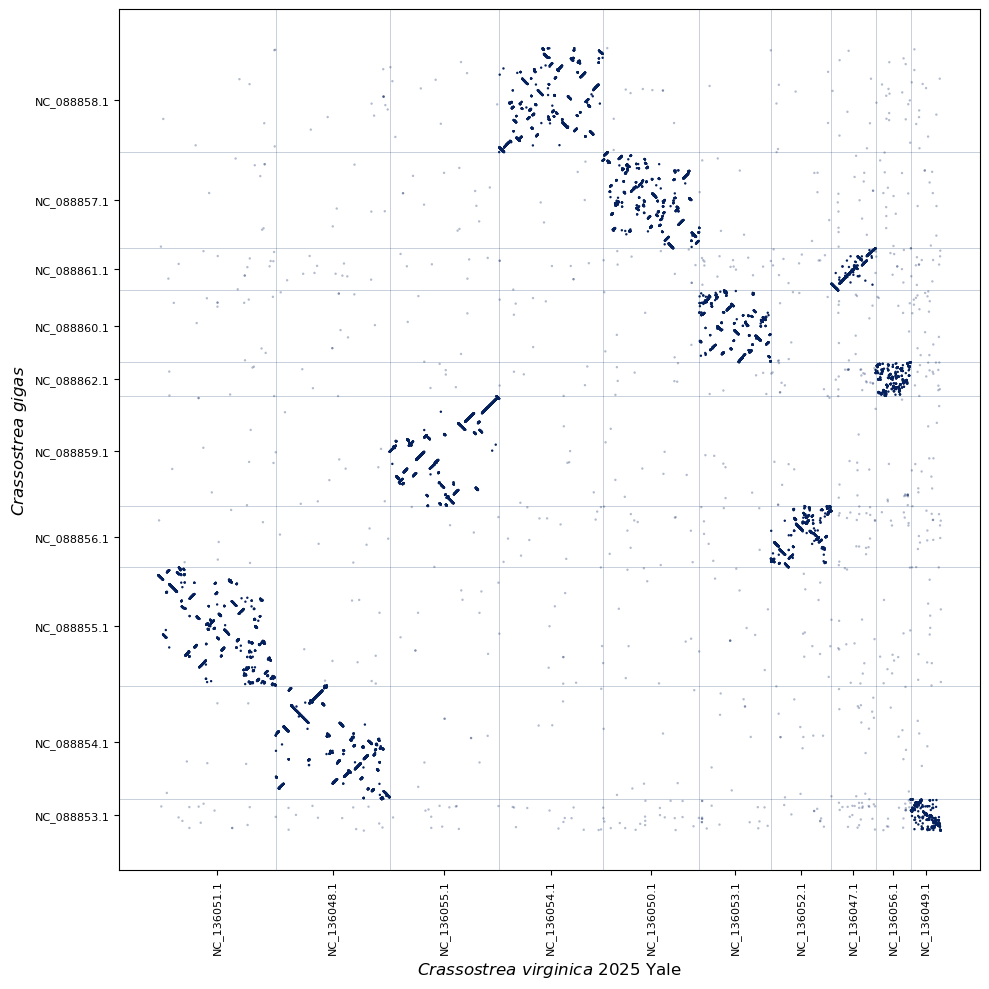

In [13]:
# Replace these with your actual paths
# rbh_file = "/work/hs325/mollusk_synteny/results/Apr3_oysters/odp/step2-figures/synteny_nocolor/Cgig_Cv2025xg_xy_reciprocal_best_hits.plotted.rbh"
# output_pdf = "/work/hs325/mollusk_synteny/results/Apr3_oysters/pdfs/Cv2025xgCgig_all.pdf"

# synteny_plot_sheet_simple(
#     df_file=rbh_file,
#     synplot=output_pdf,
#     xsample="Cv2025xg",
#     xspecies="Crassostrea virginica 2025 RU",
#     ysample="Cgig",
#     yspecies="Crassostrea gigas",
#     color = "#05215DFF"
# )

rbh_file = "/work/hs325/mollusk_synteny/results/Apr3_oysters/odp/step2-figures/synteny_nocolor/Cgig_Cv2025yale_xy_reciprocal_best_hits.plotted.rbh"
output_pdf = "/work/hs325/mollusk_synteny/results/Apr3_oysters/pdfs/Cv2025yaleCgig_all.pdf"

synteny_plot_sheet_simple(
    df_file=rbh_file,
    synplot=output_pdf,
    xsample="Cv2025yale",
    xspecies="Crassostrea virginica 2025 Yale",
    ysample="Cgig",
    yspecies="Crassostrea gigas",
    color = "#05215DFF"
)

## TODO: Custom ribbon plot

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.path import Path
import numpy as np

In [ ]:
def get_chrom_colors(chrom_list):
    """Generates a unique color for each chromosome."""
    cmap = plt.get_cmap('tab20') # Use a colormap with 20 distinct colors
    return {chrom: cmap(i % 20) for i, chrom in enumerate(chrom_list)}

def plot_ribbon_segment(ax, topx, bottomx, topy, bottomy, color, alpha):
    """Plots a Bezier-curved ribbon between two points."""
    path_data = [
        (Path.MOVETO, (topx, topy)),
        (Path.CURVE4, (topx, topy + 0.5)),
        (Path.CURVE4, (bottomx, bottomy - 0.5)),
        (Path.CURVE4, (bottomx, bottomy)),
    ]
    codes, verts = zip(*path_data)
    path = Path(verts, codes)
    patch = patches.PathPatch(path, facecolor='none', edgecolor=color, 
                              lw=0.5, alpha=alpha, zorder=1)
    ax.add_patch(patch)

def simple_ribbon_plot(species_order, rbh_files, sp_to_chr_size, outfile):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # 1. Setup Chromosome Offsets and Colors
    sp_offsets = {}
    sp_colors = {}
    
    for sp in species_order:
        # Sort chromosomes by size or name
        chroms = sorted(sp_to_chr_size[sp].keys(), key=lambda x: sp_to_chr_size[sp][x], reverse=True)
        total_len = sum(sp_to_chr_size[sp].values())
        
        # Calculate start position for each chromosome (0 to 1 scale)
        current_offset = 0
        offsets = {}
        for chr_id in chroms:
            offsets[chr_id] = current_offset / total_len
            current_offset += sp_to_chr_size[sp][chr_id]
        
        sp_offsets[sp] = offsets
        sp_colors[sp] = get_chrom_colors(chroms)

    # 2. Plot Ribbons between adjacent species
    for i in range(len(species_order) - 1):
        sp1, sp2 = species_order[i], species_order[i+1]
        df = pd.read_csv(rbh_files[i], sep="\t")
        
        # Determine total genome lengths for scaling
        len1 = sum(sp_to_chr_size[sp1].values())
        len2 = sum(sp_to_chr_size[sp2].values())

        for _, row in df.iterrows():
            c1, p1 = row[f"{sp1}_scaf"], row[f"{sp1}_pos"]
            c2, p2 = row[f"{sp2}_scaf"], row[f"{sp2}_pos"]
            
            if c1 in sp_offsets[sp1] and c2 in sp_offsets[sp2]:
                # Calculate coordinates on a 0.0 to 1.0 horizontal scale
                x1 = sp_offsets[sp1][c1] + (p1 / len1)
                x2 = sp_offsets[sp2][c2] + (p2 / len2)
                
                # Use the top species chromosome color
                color = sp_colors[sp1][c1]
                
                plot_ribbon_segment(ax, x1, x2, i, i+1, color, alpha=0.6)

    # 3. Draw Chromosome Bars
    for i, sp in enumerate(species_order):
        total_len = sum(sp_to_chr_size[sp].values())
        for chr_id, offset in sp_offsets[sp].items():
            width = sp_to_chr_size[sp][chr_id] / total_len
            ax.plot([offset, offset + width], [i, i], color='black', lw=2, solid_capstyle='butt')
            if width > 0.02: # Only label larger chromosomes
                ax.text(offset, i - 0.1, chr_id, fontsize=6, ha='left')

    # 4. Styling
    ax.set_yticks(range(len(species_order)))
    ax.set_yticklabels(species_order)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.5, len(species_order) - 0.5)
    ax.invert_yaxis()
    ax.axis('off') # Clean look
    
    # plt.savefig(outfile, dpi=300)
    plt.show()


In [ ]:
### execution
species_list = ["Cv2017", "CLG_v1.0"]
rbh_list = ["Cv2017_CLG_v1.0.rbh"]
chr_sizes = {"Cv2017": {"Chr01": 1000, "Chr02": 800}, "CLG_v1.0": {"NC_1": 1100, "NC_2": 700}}
simple_ribbon_plot(species_list, rbh_list, chr_sizes, "ribbon_output.pdf")